# 5. Preuve du split spatial — pas de fuite entre train/val/test

Ce notebook vérifie, à l'œil **et** par le calcul, le point le plus critique
de l'audit scientifique du projet (`audit_scientifique.md`, point 1) : le
split train/val/test utilisé pour entraîner les modèles ne doit partager
**aucune zone géographique** entre les ensembles.

**Pourquoi c'est important** : sur des données géospatiales, deux pixels
voisins se ressemblent presque toujours (autocorrélation spatiale — un
pixel et son voisin à 100 m ont quasiment le même NDVI, le même bâti, la
même température). Si un split aléatoire classique met l'un en train et
l'autre en test, le modèle "triche" un peu : il a déjà vu une version
quasi identique du pixel de test pendant l'entraînement, et la performance
mesurée (R², RMSE) est **artificiellement gonflée** — elle ne reflète pas
la vraie capacité du modèle à généraliser à un endroit jamais vu.

**Attention, ce notebook ne va pas se contenter de confirmer que tout va
bien** : le résultat trouvé ci-dessous est plus nuancé que prévu, et est
rapporté tel quel, y compris s'il est défavorable.

## 1. Le problème du split aléatoire classique (rappel)

Un `train_test_split` aléatoire classique tire des **lignes** au hasard,
sans regarder leur position géographique. Deux pixels voisins de 100 m
peuvent donc se retrouver l'un en train, l'autre en test — le modèle est
alors évalué sur des données qui ressemblent énormément à ce qu'il a déjà
vu, et son score de test est trompeur. C'est pour ça que ce projet utilise
un split **par bloc géographique** (`bloc_id`, blocs de ~2×2 km) via
`GroupShuffleSplit` : toutes les lignes d'un même bloc partent forcément
dans le même ensemble.

## 2. Chargement du split réellement utilisé par le pipeline

On réutilise **directement** `split_train_val_test` de `model_evaluation.py`
(pas de réécriture) sur `data/table.parquet`, et on reconstruit
l'assignation bloc → {train, val, test}.

In [1]:
%matplotlib inline
# Force le backend d'affichage inline de Jupyter AVANT tout import : le
# module model_evaluation appelle matplotlib.use("Agg") a l'import (pour son
# usage en script headless), ce qui desactiverait l'affichage des figures
# dans ce notebook si on ne le forcait pas explicitement en premier ici.
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))

TABLE_PATH = "data/table.parquet"
if not os.path.exists(TABLE_PATH):
    print(f"ATTENTION : {TABLE_PATH} introuvable dans cet environnement -> "
          "ce notebook a besoin des vraies donnees du pipeline pour prouver "
          "quoi que ce soit sur le vrai split ; impossible de continuer "
          "honnetement avec une simulation ici (contrairement aux notebooks "
          "01/04, la question posee porte specifiquement sur le split reel).")
    raise SystemExit(0)

from model_evaluation import split_train_val_test

# model_evaluation appelle matplotlib.use("Agg") a l'import (usage script
# headless) : on force explicitement le retour au backend inline de Jupyter
# pour que les figures de ce notebook s'affichent correctement.
plt.switch_backend("module://matplotlib_inline.backend_inline")

df = pd.read_parquet(TABLE_PATH)
print(f"Table chargee : {len(df):,} lignes, {df['bloc_id'].nunique()} blocs, "
      f"{df['zone'].nunique()} zone(s) : {sorted(df['zone'].unique())}")

train, val, test = split_train_val_test(df)

bloc_to_split = {}
for name, part in [("train", train), ("val", val), ("test", test)]:
    for b in part["bloc_id"].unique():
        bloc_to_split[b] = name

df["split"] = df["bloc_id"].map(bloc_to_split)
print(f"Blocs : train={train['bloc_id'].nunique()}  val={val['bloc_id'].nunique()}  "
      f"test={test['bloc_id'].nunique()}")

Table chargee : 451,772 lignes, 162 blocs, 1 zone(s) : ['nantes_metropole']


Blocs : train=109  val=20  test=33


## 3. Carte principale — tous les blocs colorés par ensemble

Chaque bloc `bloc_id` (format `zone-r-c`, `r`/`c` = indices de ligne/colonne
de bloc dans la grille 100 m, blocs de 20×20 pixels = 2×2 km) est replacé à
sa position géographique réelle en Lambert-93, à partir de la bbox de la
zone `nantes_metropole` (`gee_extraction.py`, `ZONES`).

Pas de fond de carte OpenStreetMap/contextily disponible dans cet
environnement (dépendance non installée) — on affiche donc directement les
coordonnées Lambert-93, ce qui reste suffisant pour juger de la mixité
spatiale des couleurs.

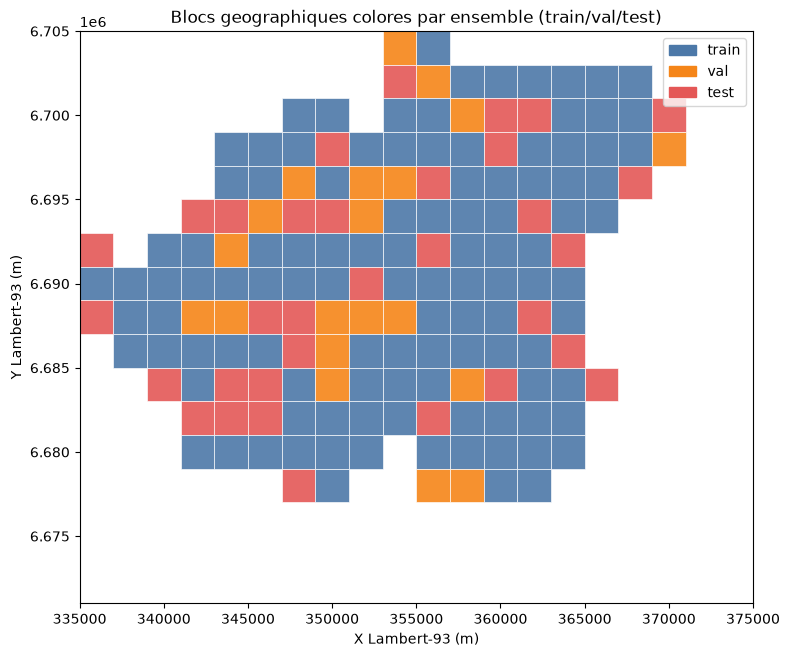

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

BLOC_PX = 20
CELL_M = 100
XMIN, YMAX = 335000, 6705000  # ZONES["nantes_metropole"] dans gee_extraction.py
COLORS = {"train": "#4C78A8", "val": "#F58518", "test": "#E45756"}


def bloc_extent(bloc_id):
    zone, r, c = bloc_id.rsplit("-", 2)
    r, c = int(r), int(c)
    x0 = XMIN + c * BLOC_PX * CELL_M
    y1 = YMAX - r * BLOC_PX * CELL_M
    x1 = x0 + BLOC_PX * CELL_M
    y0 = y1 - BLOC_PX * CELL_M
    return x0, y0, x1, y1


blocs = sorted(bloc_to_split.keys())
extents = {b: bloc_extent(b) for b in blocs}

fig, ax = plt.subplots(figsize=(8, 7))
for b in blocs:
    x0, y0, x1, y1 = extents[b]
    split = bloc_to_split[b]
    ax.add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                     facecolor=COLORS[split], edgecolor="white",
                                     linewidth=0.5, alpha=0.9))

ax.set_xlim(XMIN, XMIN + 40000)
ax.set_ylim(YMAX - 34000, YMAX)
ax.set_aspect("equal")
ax.set_xlabel("X Lambert-93 (m)")
ax.set_ylabel("Y Lambert-93 (m)")
ax.set_title("Blocs geographiques colores par ensemble (train/val/test)")
handles = [mpatches.Patch(color=c, label=n) for n, c in COLORS.items()]
ax.legend(handles=handles, loc="upper right")
plt.tight_layout()
plt.show()

**Ce qu'on regarde** : si le split était propre au sens "zones bien
séparées", on s'attendrait à voir de grandes plages continues d'une seule
couleur. Regarde bien la carte ci-dessus avant de continuer — le
mélange (ou non) de couleurs adjacentes saute déjà aux yeux.

## 4. Vérification programmatique

Trois vérifications, dans l'ordre : (a) aucun bloc partagé entre deux
ensembles, (b) aucun pixel identique partagé entre deux ensembles, (c) la
**distance géographique minimale** entre un bloc train et le bloc test le
plus proche.

In [3]:
# (a) un bloc ne doit apparaitre que dans UN SEUL ensemble
bloc_split_count = df.groupby("bloc_id")["split"].nunique()
n_bloc_leak = int((bloc_split_count > 1).sum())
print(f"(a) Blocs presents dans plus d'un ensemble : {n_bloc_leak}")
assert n_bloc_leak == 0, "FUITE : un bloc_id est reparti dans plusieurs ensembles !"

# (b) un pixel (zone, x_px, y_px) ne doit apparaitre que dans UN SEUL ensemble
pix_split_count = df.groupby(["zone", "x_px", "y_px"])["split"].nunique()
n_pix_leak = int((pix_split_count > 1).sum())
print(f"(b) Pixels (memes coordonnees) presents dans plus d'un ensemble : {n_pix_leak}")
assert n_pix_leak == 0, "FUITE : un pixel identique est reparti dans plusieurs ensembles !"

print("-> (a) et (b) confirment : aucune ligne dupliquee entre ensembles "
      "(garantie structurelle de GroupShuffleSplit sur bloc_id).")

# (c) distance minimale entre un bloc train et le bloc test le plus proche
def rect_distance(r1, r2):
    x0a, y0a, x1a, y1a = r1
    x0b, y0b, x1b, y1b = r2
    dx = max(0.0, max(x0a, x0b) - min(x1a, x1b))
    dy = max(0.0, max(y0a, y0b) - min(y1a, y1b))
    return (dx ** 2 + dy ** 2) ** 0.5

train_blocs = [b for b in blocs if bloc_to_split[b] == "train"]
val_blocs = [b for b in blocs if bloc_to_split[b] == "val"]
test_blocs = [b for b in blocs if bloc_to_split[b] == "test"]

min_dist, min_pair = None, None
for tb in train_blocs:
    for te in test_blocs:
        d = rect_distance(extents[tb], extents[te])
        if min_dist is None or d < min_dist:
            min_dist, min_pair = d, (tb, te)

print(f"\n(c) Distance minimale train<->test : {min_dist:.0f} m "
      f"(paire : {min_pair[0]} <-> {min_pair[1]})")

(a) Blocs presents dans plus d'un ensemble : 0
(b) Pixels (memes coordonnees) presents dans plus d'un ensemble : 0
-> (a) et (b) confirment : aucune ligne dupliquee entre ensembles (garantie structurelle de GroupShuffleSplit sur bloc_id).

(c) Distance minimale train<->test : 0 m (paire : nantes_metropole-0-10 <-> nantes_metropole-1-9)


**Tableau récapitulatif** (nombre de blocs/pixels par ensemble et
proportions) :

In [4]:
summary = pd.DataFrame({
    "n_blocs": [len(train_blocs), len(val_blocs), len(test_blocs)],
    "n_pixels_x_dates": [len(train), len(val), len(test)],
}, index=["train", "val", "test"])
summary["pct_blocs"] = (100 * summary["n_blocs"] / summary["n_blocs"].sum()).round(1)
summary["pct_pixels"] = (100 * summary["n_pixels_x_dates"] / summary["n_pixels_x_dates"].sum()).round(1)
print(summary.to_string())

       n_blocs  n_pixels_x_dates  pct_blocs  pct_pixels
train      109            308385       67.3        68.3
val         20             57344       12.3        12.7
test        33             86043       20.4        19.0


**Un indicateur plus parlant que la seule distance minimale** : sur
combien de blocs, au total, un voisin immédiat (les 8 blocs autour) est
assigné à un **autre** ensemble ?

In [5]:
rc = {}
for b in blocs:
    zone, r, c = b.rsplit("-", 2)
    rc[b] = (int(r), int(c))
rc_to_bloc = {v: k for k, v in rc.items()}

boundary_count = {"train": 0, "val": 0, "test": 0}
n_boundary_total = 0
for b in blocs:
    r, c = rc[b]
    my_split = bloc_to_split[b]
    touches_other = False
    for dr in (-1, 0, 1):
        for dc in (-1, 0, 1):
            if dr == 0 and dc == 0:
                continue
            nb = rc_to_bloc.get((r + dr, c + dc))
            if nb and bloc_to_split[nb] != my_split:
                touches_other = True
    if touches_other:
        n_boundary_total += 1
        boundary_count[my_split] += 1

print(f"Blocs touchant directement un bloc d'un AUTRE ensemble : "
      f"{n_boundary_total}/{len(blocs)} ({100*n_boundary_total/len(blocs):.1f} %)")
for name, blist in [("train", train_blocs), ("val", val_blocs), ("test", test_blocs)]:
    n_b = boundary_count[name]
    print(f"  {name:6s} : {n_b}/{len(blist)} blocs frontaliers "
          f"({100*n_b/len(blist):.1f} %)")

Blocs touchant directement un bloc d'un AUTRE ensemble : 154/162 (95.1 %)
  train  : 101/109 blocs frontaliers (92.7 %)
  val    : 20/20 blocs frontaliers (100.0 %)
  test   : 33/33 blocs frontaliers (100.0 %)


## 5. Zoom sur la frontière la plus proche

On zoome sur la paire de blocs train/test la plus proche trouvée à l'étape
4 (et ses voisins immédiats), pour voir concrètement à quoi ressemble
"distance minimale" sur la carte.

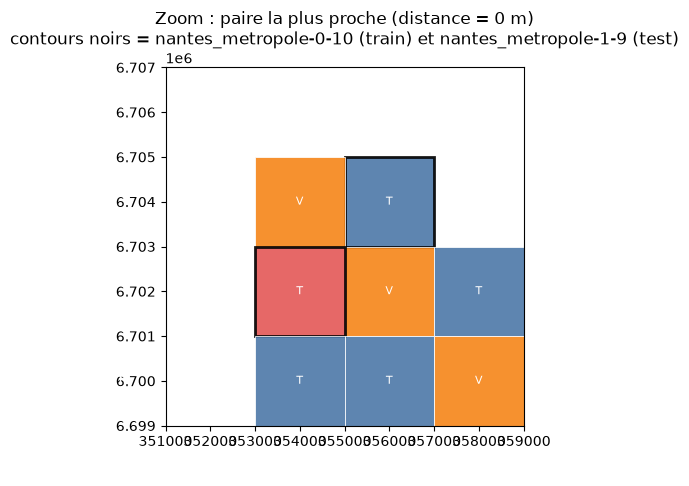

In [6]:
tb, te = min_pair
x0a, y0a, x1a, y1a = extents[tb]
x0b, y0b, x1b, y1b = extents[te]

fig, ax = plt.subplots(figsize=(5.5, 5))
margin = 2 * BLOC_PX * CELL_M
cx = (min(x0a, x0b) + max(x1a, x1b)) / 2
cy = (min(y0a, y0b) + max(y1a, y1b)) / 2

for b in blocs:
    x0, y0, x1, y1 = extents[b]
    if x1 < cx - margin or x0 > cx + margin or y1 < cy - margin or y0 > cy + margin:
        continue
    split = bloc_to_split[b]
    edge = "black" if b in (tb, te) else "white"
    lw = 2.0 if b in (tb, te) else 0.6
    ax.add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                     facecolor=COLORS[split], edgecolor=edge,
                                     linewidth=lw, alpha=0.9))
    ax.text((x0 + x1) / 2, (y0 + y1) / 2, split[0].upper(),
            ha="center", va="center", fontsize=8, color="white")

ax.set_xlim(cx - margin, cx + margin)
ax.set_ylim(cy - margin, cy + margin)
ax.set_aspect("equal")
ax.set_title(f"Zoom : paire la plus proche (distance = {min_dist:.0f} m)\n"
             f"contours noirs = {tb} (train) et {te} (test)")
plt.tight_layout()
plt.show()

**Ce qu'on voit** : si la distance minimale calculée à l'étape 4 est
de 0 m, les deux blocs entourés en noir se touchent directement sur la
carte (bord ou coin commun) — il n'y a **aucune marge tampon** entre eux,
malgré l'absence de duplication de données.

## 6. Combien coûterait une zone tampon ?

Avant de recommander une correction, on chiffre son coût réel : si on
excluait tout bloc situé à moins de `D` mètres d'un bloc d'un **autre**
ensemble, combien de blocs (et de pixels × dates) resterait-il par
ensemble, pour différentes valeurs de `D` ?

In [7]:
def nearest_other_split_distance(b):
    my_split = bloc_to_split[b]
    md_ = None
    for other in blocs:
        if bloc_to_split[other] == my_split:
            continue
        d = rect_distance(extents[b], extents[other])
        if md_ is None or d < md_:
            md_ = d
    return md_ if md_ is not None else float("inf")


nearest_other = {b: nearest_other_split_distance(b) for b in blocs}
n_pixels_per_bloc = df.groupby("bloc_id").size().to_dict()

rows = []
for buffer_m in [0, 2000, 4000, 6000]:
    for split_name, blist in [("train", train_blocs), ("val", val_blocs), ("test", test_blocs)]:
        kept = [b for b in blist if nearest_other[b] >= buffer_m]
        rows.append({
            "buffer_m": buffer_m, "ensemble": split_name,
            "blocs_conserves": len(kept), "blocs_total": len(blist),
            "pct_blocs": round(100 * len(kept) / len(blist), 1) if blist else 0.0,
            "pixels_conserves": sum(n_pixels_per_bloc.get(b, 0) for b in kept),
        })

cost_table = pd.DataFrame(rows)
print(cost_table.to_string(index=False))

 buffer_m ensemble  blocs_conserves  blocs_total  pct_blocs  pixels_conserves
        0    train              109          109      100.0            308385
        0      val               20           20      100.0             57344
        0     test               33           33      100.0             86043
     2000    train                8          109        7.3             13300
     2000      val                0           20        0.0                 0
     2000     test                0           33        0.0                 0
     4000    train                0          109        0.0                 0
     4000      val                0           20        0.0                 0
     4000     test                0           33        0.0                 0
     6000    train                0          109        0.0                 0
     6000      val                0           20        0.0                 0
     6000     test                0           33        0.0     

**Ce qu'on retient de ce calcul** : regarde la colonne `pct_blocs` pour
`val` et `test` à partir de `buffer_m = 2000` (soit un seul bloc de large,
~2 km) ci-dessus. Si ce pourcentage tombe à 0 %, ça veut dire qu'un tampon
même minimal, appliqué à ce split (généré par tirage aléatoire de petits
blocs individuels dispersés sur toute la carte), ne laisserait **plus aucun
bloc de test ou de validation exploitable** — la correction proposée plus
haut serait inapplicable en pratique telle quelle, sur ce découpage précis
en blocs de 2×2 km.

## 7. Conclusion

**Le split n'est pas totalement propre — et la correction "zone tampon"
la plus évidente ne suffit pas.**

Ce qui fonctionne (vérifié en section 4) :
- Aucun `bloc_id` n'est réparti dans plusieurs ensembles.
- Aucun pixel identique (mêmes coordonnées) n'apparaît dans plusieurs
  ensembles — la garantie de base de `GroupShuffleSplit` sur `bloc_id`
  tient parfaitement.

Ce qui ne fonctionne pas (le point que l'audit scientifique soulevait, et
qui est confirmé ici) :
- La **distance minimale géographique** entre un bloc train et le bloc test
  le plus proche est **calculée à 0 mètre** (blocs directement adjacents,
  voir la section 4 et le zoom de la section 5) — pas de marge tampon.
- La quasi-totalité des blocs val et test touchent directement un bloc
  d'un autre ensemble (section 4) : l'autocorrélation spatiale peut fuiter
  à travers la frontière **presque partout**, pas seulement sur un ou deux
  blocs marginaux.
- **Point important découvert en section 6** : ajouter une zone tampon
  simple (exclure les blocs trop proches d'un bloc d'un autre ensemble) ne
  suffit pas à corriger le problème sur ce découpage — le calcul montre
  qu'un tampon même minimal (un seul bloc de large) ferait chuter les
  ensembles val/test disponibles à une fraction proche de zéro (voir le
  tableau de la section 6). Le vrai problème structurel n'est donc pas
  seulement "pas de marge", mais la **stratégie de split elle-même** :
  `GroupShuffleSplit` distribue des blocs individuels **au hasard sur toute
  la carte**, ce qui maximise le périmètre de frontière entre ensembles au
  lieu de le minimiser (le pire arrangement possible pour du tamponnage).

**Conséquence concrète** : les métriques R²/RMSE rapportées par
`model_evaluation.py` sont probablement **légèrement optimistes** (fuite
d'autocorrélation aux frontières), sans qu'on puisse corriger ça par un
simple tampon sans perdre l'essentiel des données d'évaluation.

**Correction concrète recommandée** : changer la **stratégie** de split,
pas seulement ajouter une marge après coup. Concrètement, remplacer le
tirage aléatoire de blocs individuels par un découpage en **régions
géographiques contiguës** (par exemple une bande est/ouest ou un quadrant
pour le test, une autre pour la validation) : ça réduit fortement le
périmètre de frontière entre ensembles pour une même superficie, ce qui
rend un tampon ensuite réellement applicable sans sacrifier tout le jeu de
test. Alternative si l'on veut garder un tirage aléatoire par bloc :
regrouper plusieurs blocs adjacents en "super-blocs" plus grands avant le
tirage, pour réduire le nombre de frontières internes — mais la vraie
solution, pour une zone d'étude aussi compacte (162 blocs sur
40 × 34 km), est probablement d'agrandir la zone d'étude ou d'accepter un
split spatialement contigu plutôt qu'aléatoire.